In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import glob, os, torch
from depth_anything_3.api import DepthAnything3

[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


In [5]:
device = torch.device("cuda")

In [6]:
model_name = "depth-anything/DA3-BASE"

In [7]:
model = DepthAnything3.from_pretrained(model_name)

[INFO ] using MLP layer as FFN


In [8]:
model = model.to(device=device)

In [13]:
from PIL import Image

In [14]:
image = Image.open("../../../../data/depth_measurements/full_image.png")

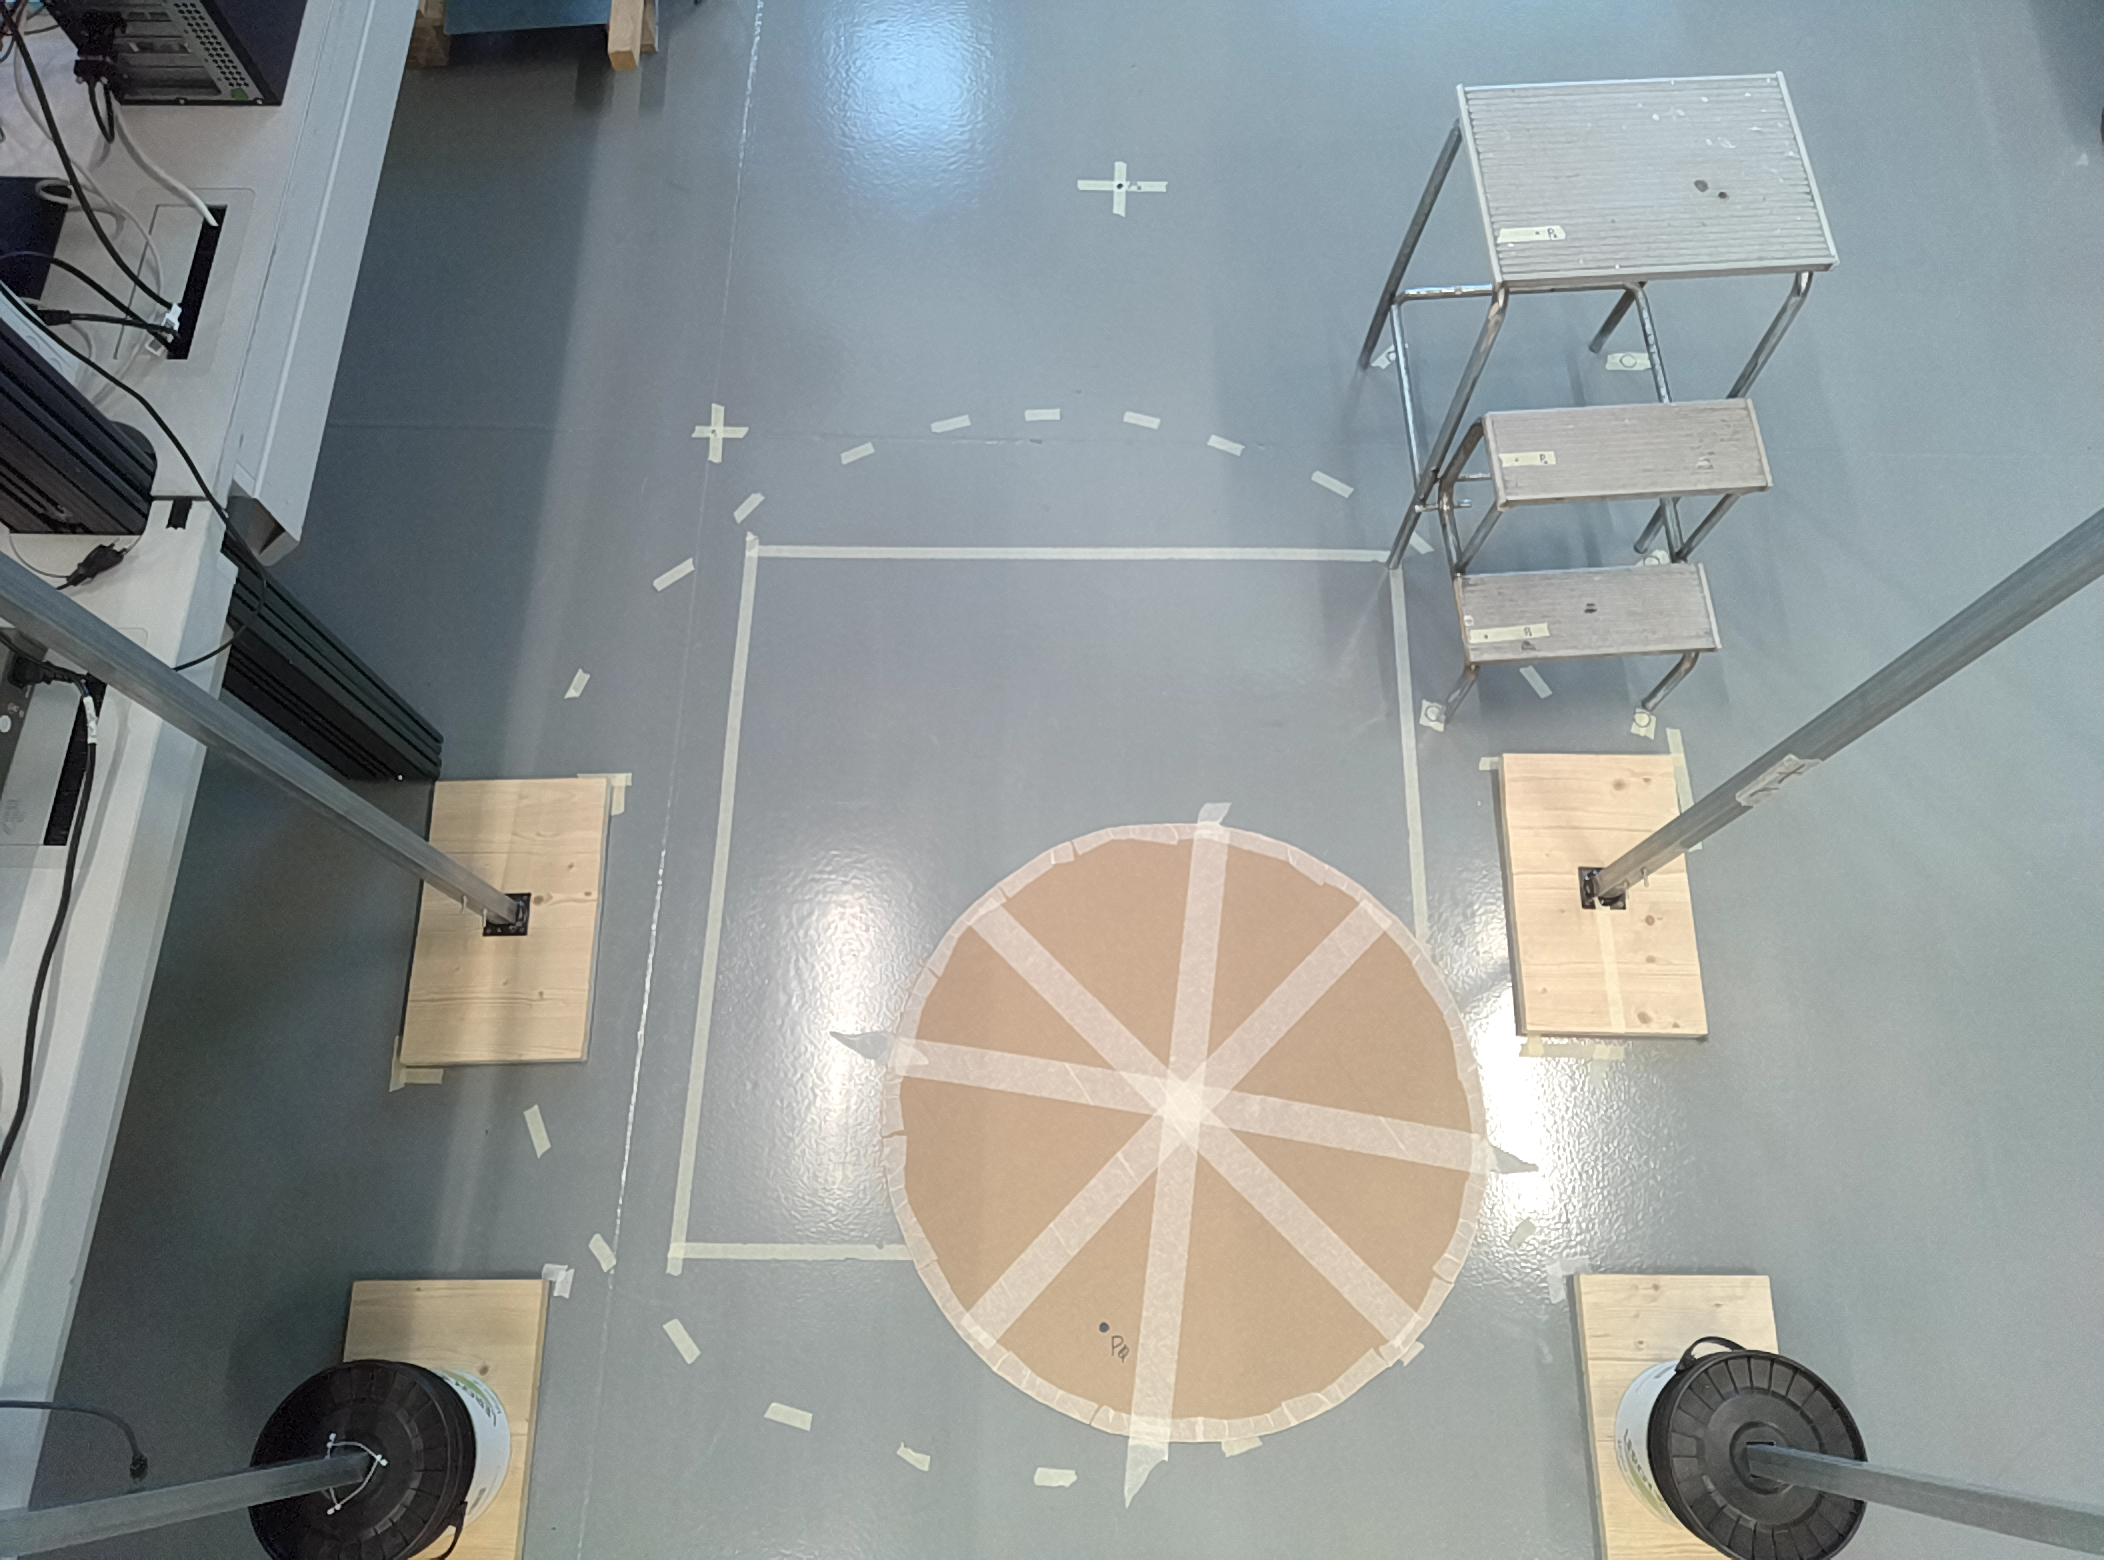

In [15]:
image

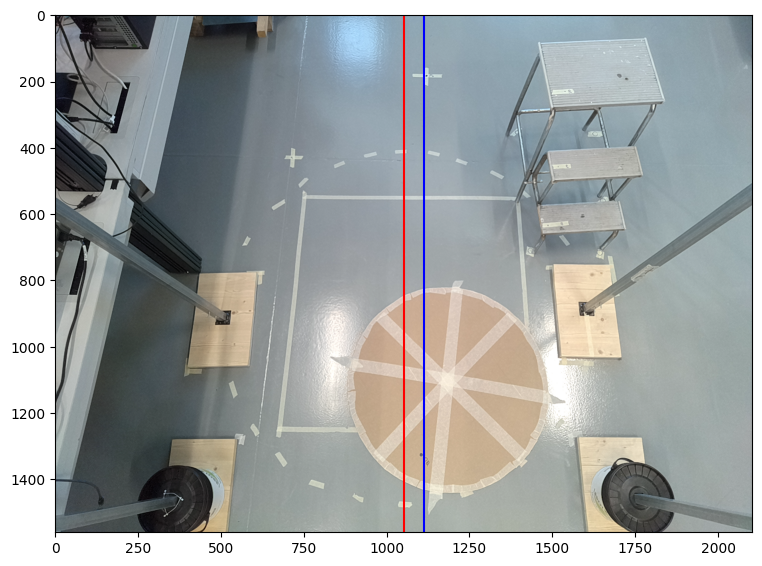

In [79]:

fig, ax = plt.subplots(figsize=(9, 12))
plt.imshow(image)
plt.axvline(x=2104/2, c="red")
plt.axvline(x=2104/2 + 60, c="b")
plt.show()

In [16]:
cam_intrinsics = np.array([
    [1.64352741e+03, 0.00000000e+00, 1.06707005e+03],
    [0.00000000e+00, 2.16623503e+03, 7.62798557e+02],
    [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]
])

In [17]:
# Original 4x4 extrinsics matrix
cam_extrinsics = np.array([
    [ 9.42588070e-01,  3.12367629e-03,  3.33943070e-01,  0.00000000e+00],
    [ 0.00000000e+00, -9.99956255e-01,  9.35350941e-03,  0.00000000e+00],
    [ 3.33957679e-01, -8.81650638e-03, -9.42546836e-01, -2.08000000e+03],
    [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00]
])

In [18]:
prediction = model.inference([image],
    export_dir="output",
    extrinsics=cam_extrinsics[None, :, :],
    intrinsics=cam_intrinsics[None, :, :],
)

[INFO ] Processed Images Done taking 0.03279376029968262 seconds. Shape:  torch.Size([1, 3, 378, 504])
[INFO ] Using camera conditions provided by the user
[INFO ] Model Forward Pass Done. Time: 0.3955199718475342 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0008766651153564453 seconds
[INFO ] Export Results Done. Time: 0.00025725364685058594 seconds


In [19]:
prediction.depth.shape

(1, 378, 504)

In [58]:
depth_map = prediction.depth[0]

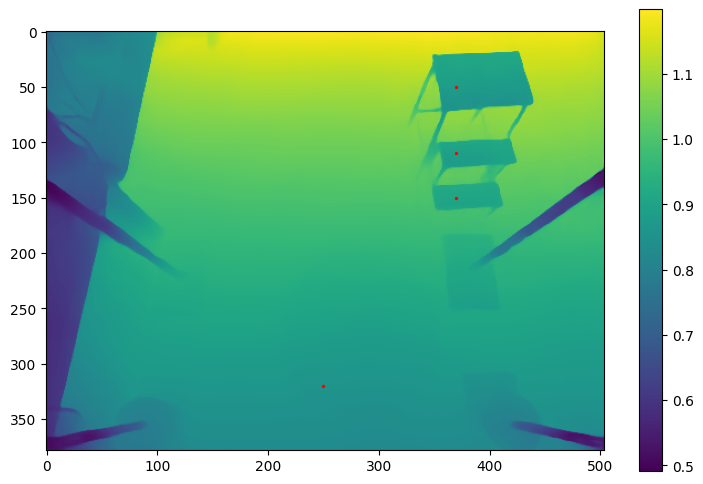

In [59]:
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(depth_map)
ax.scatter(370, 50, c="red", s=2)
ax.scatter(370, 110, c="red", s=2)
ax.scatter(370, 150, c="red", s=2)
ax.scatter(250, 320, c="red", s=2)

fig.colorbar(im, orientation='vertical')
plt.show()

In [54]:
depth_map[50, 370]

0.8829228

In [55]:
depth_map[110, 370]

0.89093596

In [56]:
depth_map[150, 370]

0.90703815

In [82]:
depth_map[310, 250]

0.8636358

# Metric analysis

In [22]:
data = {
    "Point": ["P0", "C0", "P1", "P2", "P3", "P4", "P5"],
    "x": [0, 0, 1800, 1300, 900, 1050, 1230],
    "y": [0, 0, 0, -650, 510, 510, 510],
    "z": [0, -2080, 0, 0, -220, -420, -620],
    "x_img": [273, 273, 277, 172, 369, 380, 389],
    "y_img": [446, 446, 54, 139, 208, 147, 70]
}

In [23]:
df = pd.DataFrame(data)

In [24]:
# Calculate distance from C0 (skip C0 itself)
C0_coords = np.array([0, 0, -2080])
df["distance"] = df.apply(
    lambda row: np.linalg.norm(np.array([row["x"], row["y"], row["z"]]) - C0_coords),
    axis=1
)

In [25]:
df["depth_level"] = df.apply(
    lambda row: depth_map[int(row["y_img"]), int(row["x_img"])]
                if not pd.isna(row["x_img"]) and not pd.isna(row["y_img"]) else np.nan,
    axis=1
)

IndexError: index 446 is out of bounds for axis 0 with size 378

In [ ]:
df

In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(depth_map, cmap="grey")
ax.scatter(df["x_img"], df["y_img"], marker='o', s=10, c="red")

# Plot lines from P0 (assume P0 is first row) to other points
x0, y0 = df.loc[0, "x_img"], df.loc[0, "y_img"]

for idx, (point_id, x, y, dist, depth) in enumerate(zip(df["Point"], df["x_img"], df["y_img"], df["distance"], df["depth_level"])):
    # Skip line for P0 itself
    if idx != 0:
        ax.plot([x0, x], [y0, y], '-.', linewidth=1)
    
    # Offset label for C0 to avoid overlap
    if idx == 1:  # C0
        label_x = x + 40
        label_y = y - 40
    else:
        label_x = x - 30
        label_y = y - 10
    
    ax.text(label_x, label_y, f"{point_id} ({x},{y}),\n$d_{{{{C0}}-P}} = {dist:.2f}$ [mm]\ndepth = {depth:.2f}", color='k')


plt.show()